# Session 3 — Measuring and Aggregating Abnormal Returns

**Course: Event Studies in Finance & Economics**

*Mathis Mourey*

---

In this session, we address the aggregation problem in full. We introduce cross-sectional averaging, examine the choice between equal-weighted and value-weighted aggregation, and confront the practical complications of missing data and thin trading. We then establish the graphical conventions that have become standard in the literature for presenting event study results. The session closes by assembling the reusable Python toolkit that will carry forward into all subsequent sessions.

The progression is as follows. We begin with a multi-firm dataset, estimate normal returns for each firm, and compute individual CARs. We then aggregate across firms under various weighting schemes and visualize the results. Throughout, we pay careful attention to the variance of the aggregated statistics, since correct inference (Sessions 4 and 5) requires correct variance estimates.

**References for this session:**

- Brown, S.J. and Warner, J.B. (1980). Measuring Security Price Performance. *Journal of Financial Economics*, 8(3), 205--258.
- Brown, S.J. and Warner, J.B. (1985). Using Daily Stock Returns. *Journal of Financial Economics*, 14(1), 3--31.
- Campbell, J.Y., Lo, A.W. and MacKinlay, A.C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 4.
- Kolari, J.W. and Pynnonen, S. (2010). Event Study Testing with Cross-sectional Correlation of Abnormal Returns. *Review of Financial Studies*, 23(11), 3996--4025.
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13--39.
- Patell, J.M. (1976). Corporate Forecasts of Earnings Per Share and Stock Price Behavior. *Journal of Accounting Research*, 14(2), 246--276.
- Scholes, M. and Williams, J. (1977). Estimating Betas from Nonsynchronous Data. *Journal of Financial Economics*, 5(3), 309--327.

## 1. From Single-Firm to Cross-Sectional Inference

A single-firm event study measures whether a specific event affected one firm's stock price. While this is sometimes the research question (e.g., did a particular merger create value for the acquirer?), most studies ask a broader question: on average, does a certain type of event affect firm value?

Answering this question requires aggregating abnormal returns across multiple firms. The aggregation serves two purposes. First, it averages out the idiosyncratic noise in individual firms' returns, increasing the signal-to-noise ratio. Second, it allows us to make general statements about a class of events rather than one particular instance.

Recall from Session 1 that the abnormal return for firm $i$ on event day $\tau$ is:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{R}_{i,\tau}
$$

The cumulative abnormal return over the event window $[\tau_a, \tau_b]$ is:

$$
CAR_i(\tau_a, \tau_b) = \sum_{\tau=\tau_a}^{\tau_b} AR_{i,\tau}
$$

The cross-sectional aggregation proceeds in two steps. First, we compute the **average abnormal return** (AAR) on each event day. Second, we cumulate the AARs to obtain the **cumulative average abnormal return** (CAAR).

$$
AAR(\tau) = \frac{1}{N} \sum_{i=1}^{N} AR_{i,\tau}
$$

$$
CAAR(\tau_a, \tau_b) = \sum_{\tau=\tau_a}^{\tau_b} AAR(\tau) = \frac{1}{N} \sum_{i=1}^{N} CAR_i(\tau_a, \tau_b)
$$

The second equality holds because summation over $\tau$ and over $i$ can be exchanged. This means CAAR can equivalently be computed by first cumulating each firm's ARs into a CAR, then averaging across firms, or by first averaging across firms on each day (AAR), then cumulating. The two routes produce identical results, but the second is more convenient for plotting and for computing daily variance estimates.

## 2. Variance of the CAAR

The variance of the CAAR determines the precision of the aggregate estimate and is the denominator of all test statistics (Sessions 4--5). Its form depends on whether the abnormal returns are cross-sectionally independent.

### 2.1 Independent Abnormal Returns

If the $N$ events do not cluster on the same calendar dates, the abnormal returns $AR_{i,\tau}$ are independent across $i$ (conditional on the market return). In this case:

$$
\text{Var}\left(AAR(\tau)\right) = \frac{1}{N^2} \sum_{i=1}^{N} \sigma^2_{\varepsilon_i}
$$

and, assuming no serial correlation in abnormal returns:

$$
\text{Var}\left(CAAR(\tau_a, \tau_b)\right) = \sum_{\tau=\tau_a}^{\tau_b} \text{Var}\left(AAR(\tau)\right) = \frac{T_w}{N^2} \sum_{i=1}^{N} \sigma^2_{\varepsilon_i}
$$

where $T_w = \tau_b - \tau_a + 1$ is the length of the event window. With equal residual variances $\sigma^2_{\varepsilon}$ across firms, this simplifies to $T_w \sigma^2_\varepsilon / N$.

### 2.2 Cross-Sectionally Correlated Abnormal Returns

When events cluster in calendar time (e.g., all firms in the sample report earnings in the same week, or a regulatory shock affects all firms simultaneously), the abnormal returns share a common component driven by market-wide shocks during the event window. In this case:

$$
\text{Var}\left(AAR(\tau)\right) = \frac{1}{N^2} \sum_{i=1}^{N} \sum_{j=1}^{N} \text{Cov}(AR_{i,\tau}, AR_{j,\tau})
$$

The off-diagonal covariance terms do not vanish, and the variance of the CAAR can be substantially larger than the independent case suggests. Ignoring this correlation leads to over-rejection of the null hypothesis (too many false positives). Kolari and Pynnonen (2010) document this problem and propose corrections, which we will implement in Session 4.

For now, we note that the simplest way to handle clustering is to estimate the variance of the AAR directly from the cross-section of abnormal returns on each event day, rather than using the time-series residual variances. This is the **cross-sectional variance estimator**:

$$
\hat{\text{Var}}(AAR(\tau)) = \frac{1}{N(N-1)} \sum_{i=1}^{N} \left(AR_{i,\tau} - AAR(\tau)\right)^2
$$

This estimator is robust to cross-sectional correlation because it uses the realized dispersion of abnormal returns across firms, which naturally incorporates any common component.

## 3. Multi-Firm Event Study: Data and Setup

To illustrate cross-sectional aggregation concretely, we construct a small event study of earnings announcements. We select a sample of large-cap US stocks and study their most recent Q4 2023 earnings announcements (reported in January--February 2024). This is a canonical application: the events are well-dated, the firms are liquid, and the sample is large enough to illustrate the aggregation mechanics.

We use the market model as the normal return benchmark, with a 250-day estimation window and a 10-day buffer, consistent with Sessions 1 and 2.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# -- Sample of firms and their earnings announcement dates (Q4 2023) --
events = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'JPM', 'JNJ', 'V', 'PG'],
    'event_date': pd.to_datetime([
        '2024-02-01', '2024-01-30', '2024-01-30', '2024-02-01',
        '2024-02-01', '2024-02-21', '2024-01-12', '2024-01-23',
        '2024-01-25', '2024-01-23'
    ]),
    'name': ['Apple', 'Microsoft', 'Alphabet', 'Amazon', 'Meta',
             'NVIDIA', 'JPMorgan', 'Johnson & Johnson', 'Visa', 'Procter & Gamble'],
})

print(f"Sample: {len(events)} firms")
print(events.to_string(index=False))

Sample: 10 firms
ticker event_date              name
  AAPL 2024-02-01             Apple
  MSFT 2024-01-30         Microsoft
 GOOGL 2024-01-30          Alphabet
  AMZN 2024-02-01            Amazon
  META 2024-02-01              Meta
  NVDA 2024-02-21            NVIDIA
   JPM 2024-01-12          JPMorgan
   JNJ 2024-01-23 Johnson & Johnson
     V 2024-01-25              Visa
    PG 2024-01-23  Procter & Gamble


In [5]:
# -- Download all price data --
market_ticker = '^GSPC'
start_date = '2022-06-01'
end_date = '2024-04-01'

data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)
if isinstance(data_market.columns, pd.MultiIndex):
    data_market.columns = data_market.columns.get_level_values(0)
market_prices = data_market['Close']

all_tickers = events['ticker'].tolist()
data_firms = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
if isinstance(data_firms.columns, pd.MultiIndex):
    firm_prices = data_firms['Close']
else:
    firm_prices = data_firms[['Close']]
    firm_prices.columns = all_tickers

firm_returns = np.log(firm_prices / firm_prices.shift(1)).dropna()
market_returns = np.log(market_prices / market_prices.shift(1)).dropna()

firm_returns.index = firm_returns.index.tz_localize(None)
market_returns.index = market_returns.index.tz_localize(None)
common_idx = firm_returns.index.intersection(market_returns.index)
firm_returns = firm_returns.loc[common_idx]
market_returns = market_returns.loc[common_idx]

print(f"Return data: {firm_returns.index[0].date()} to {firm_returns.index[-1].date()}")
print(f"Trading days: {len(firm_returns)}, Firms: {list(firm_returns.columns)}")

YF.download() has changed argument auto_adjust default to True
Return data: 2022-06-02 to 2024-03-28
Trading days: 458, Firms: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'PG', 'V']


## 4. Estimating the Market Model for Each Firm

We now loop over the sample, estimating the market model for each firm over its estimation window and computing abnormal returns in its event window. Each firm has its own event date, so the estimation and event windows are firm-specific (they are defined in event time, not calendar time).

This is the standard procedure in multi-firm event studies. The output is a panel of abnormal returns indexed by firm and event day.

In [7]:
est_window_length = 250
buffer = 10
event_win = (-10, 10)
event_days = list(range(event_win[0], event_win[1] + 1))

trading_days = firm_returns.index

ar_panel = pd.DataFrame(index=event_days, columns=events['ticker'].values, dtype=float)
model_params = {}

for _, row in events.iterrows():
    tick = row['ticker']
    edate = row['event_date']

    event_idx = trading_days.get_indexer([edate], method='ffill')[0]

    event_start = event_idx + event_win[0]
    event_end = event_idx + event_win[1]
    est_end = event_start - buffer - 1
    est_start = est_end - est_window_length + 1

    if est_start < 0 or event_end >= len(trading_days):
        print(f"  {tick}: insufficient data, skipping.")
        continue

    y_est = firm_returns[tick].iloc[est_start:est_end + 1].values
    x_est = market_returns.iloc[est_start:est_end + 1].values
    y_evt = firm_returns[tick].iloc[event_start:event_end + 1].values
    x_evt = market_returns.iloc[event_start:event_end + 1].values

    valid_est = ~(np.isnan(y_est) | np.isnan(x_est))
    y_est_clean = y_est[valid_est]
    x_est_clean = x_est[valid_est]

    X_est = sm.add_constant(x_est_clean)
    ols = sm.OLS(y_est_clean, X_est).fit()
    alpha, beta = ols.params
    sigma = np.sqrt(ols.mse_resid)

    ar = y_evt - (alpha + beta * x_evt)
    ar_panel[tick] = ar

    model_params[tick] = {
        'alpha': alpha, 'beta': beta, 'sigma': sigma,
        'r_squared': ols.rsquared, 'n_obs': len(y_est_clean)
    }

print("Market model estimated for all firms.\n")
params_df = pd.DataFrame(model_params).T
params_df.index.name = 'Ticker'
print(params_df.round(4).to_string())

Market model estimated for all firms.

         alpha    beta   sigma  r_squared  n_obs
Ticker                                          
AAPL    0.0006  1.1132  0.0089     0.5179  250.0
MSFT    0.0008  1.1772  0.0124     0.3804  250.0
GOOGL   0.0006  1.3846  0.0154     0.3550  250.0
AMZN    0.0009  1.5426  0.0164     0.3769  250.0
META    0.0026  1.7496  0.0192     0.3606  250.0
NVDA    0.0030  2.0100  0.0238     0.3123  250.0
JPM     0.0003  0.8549  0.0109     0.3111  250.0
JNJ    -0.0007  0.3361  0.0100     0.0737  250.0
V       0.0003  0.7630  0.0075     0.4199  250.0
PG     -0.0004  0.3769  0.0089     0.1125  250.0


## 5. Computing AAR and CAAR

With the panel of abnormal returns in hand, we compute the average abnormal return (AAR) on each event day and the cumulative average abnormal return (CAAR). We also compute the cross-sectional standard error of the AAR, which will be used for inference.

In [9]:
N = ar_panel.shape[1]
aar = ar_panel.mean(axis=1)
caar = aar.cumsum()

# Cross-sectional standard error of AAR
aar_se = ar_panel.std(axis=1, ddof=1) / np.sqrt(N)
aar_t = aar / aar_se

# CAAR variance: sum of daily variances (assuming no serial correlation in AAR)
caar_var = (aar_se ** 2).cumsum()
caar_se = np.sqrt(caar_var)

agg_table = pd.DataFrame({
    'AAR (%)': aar * 100,
    'AAR SE (%)': aar_se * 100,
    'AAR t-stat': aar_t,
    'CAAR (%)': caar * 100,
    'CAAR SE (%)': caar_se * 100,
}, index=event_days)
agg_table.index.name = 'Event Day'

print("Equal-Weighted AAR and CAAR")
print("=" * 70)
print(agg_table.round(4).to_string())

Equal-Weighted AAR and CAAR
           AAR (%)  AAR SE (%)  AAR t-stat  CAAR (%)  CAAR SE (%)
Event Day                                                        
-10         0.1664      0.3559      0.4675    0.1664       0.3559
-9          0.0595      0.1442      0.4128    0.2259       0.3840
-8         -0.0033      0.2671     -0.0122    0.2226       0.4677
-7          0.3624      0.2122      1.7077    0.5850       0.5136
-6          0.2105      0.2236      0.9415    0.7956       0.5602
-5         -0.0116      0.2910     -0.0399    0.7839       0.6312
-4          0.1214      0.2354      0.5155    0.9053       0.6737
-3         -0.4384      0.3770     -1.1627    0.4669       0.7720
-2         -0.4527      0.2388     -1.8958    0.0143       0.8081
-1         -0.3177      0.3695     -0.8599   -0.3034       0.8885
 0         -0.4440      0.6063     -0.7323   -0.7474       1.0757
 1          2.0860      2.1428      0.9735    1.3386       2.3977
 2          0.0530      0.4585      0.1157    1.

## 6. Weighting Schemes: Equal-Weighted vs. Value-Weighted

The equal-weighted CAAR gives each firm the same influence on the aggregate result, regardless of firm size. This is the standard in most event studies and is appropriate when the research question concerns the average firm.

An alternative is the **value-weighted** CAAR, where each firm's CAR is weighted by its market capitalization (typically measured just before the event window). Value-weighting reflects the economic magnitude of the event: a 1% abnormal return on Apple (market cap > \$2 trillion) represents a much larger change in total wealth than a 1% return on a mid-cap firm.

The value-weighted AAR is:

$$
AAR^{VW}(\tau) = \sum_{i=1}^{N} w_i \cdot AR_{i,\tau}, \qquad w_i = \frac{\text{MCap}_i}{\sum_{j=1}^{N} \text{MCap}_j}
$$

The choice between equal- and value-weighting depends on the research question. Equal-weighting tests whether the average event has a price impact. Value-weighting tests whether the aggregate wealth effect is nonzero. The two can give different answers when small firms show large abnormal returns that are diluted in the value-weighted aggregate, or vice versa. Reporting both is good practice.

In [11]:
# -- Retrieve approximate market caps --
market_caps = {}
for tick in events['ticker']:
    try:
        info = yf.Ticker(tick).info
        mc = info.get('marketCap', None)
        if mc is not None:
            market_caps[tick] = mc
    except Exception:
        pass

missing = [t for t in events['ticker'] if t not in market_caps]
if missing:
    print(f"Missing market cap data for: {missing}. Using equal weights as fallback.")
    for t in missing:
        market_caps[t] = 1.0

mcap_series = pd.Series(market_caps)
weights = mcap_series / mcap_series.sum()

print("Market Capitalization Weights")
print("=" * 40)
for tick in events['ticker']:
    print(f"  {tick:<6}  {weights[tick]:.4f}  (${mcap_series[tick]/1e9:.0f}B)")

Market Capitalization Weights
  AAPL    0.1801  ($3784B)
  MSFT    0.1447  ($3040B)
  GOOGL   0.1719  ($3611B)
  AMZN    0.1089  ($2288B)
  META    0.0776  ($1631B)
  NVDA    0.2058  ($4323B)
  JPM     0.0372  ($781B)
  JNJ     0.0276  ($579B)
  V       0.0291  ($612B)
  PG      0.0171  ($359B)


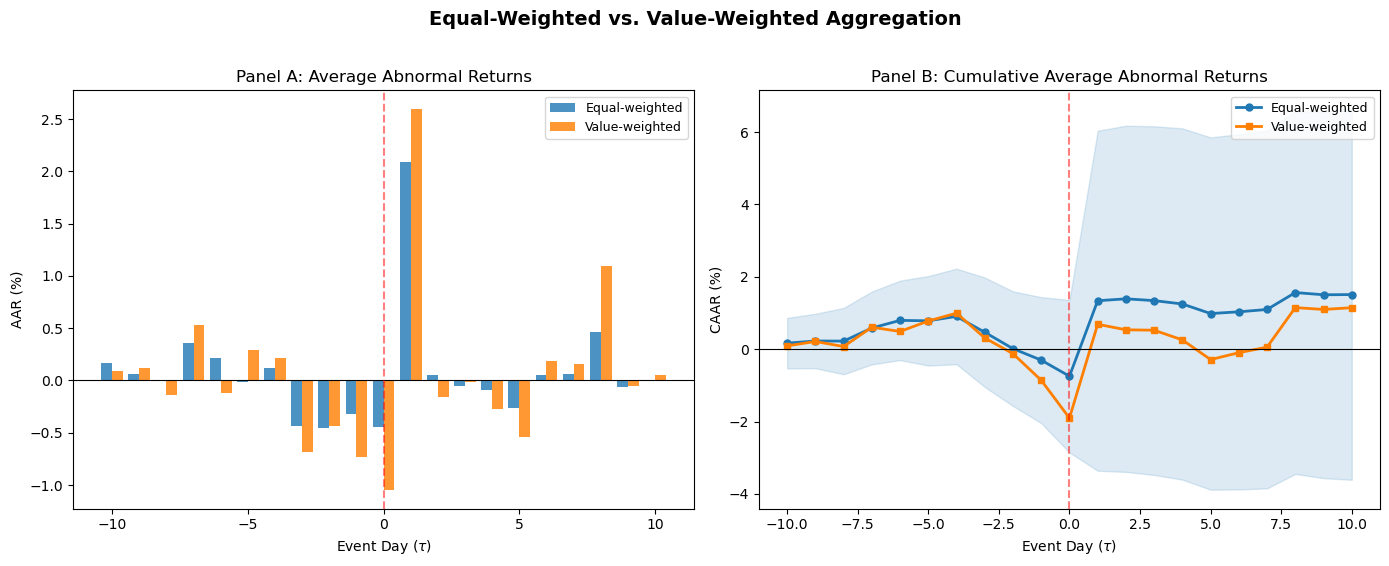

In [13]:
# -- Value-weighted AAR and CAAR --
w = weights[ar_panel.columns].values
aar_vw = (ar_panel * w).sum(axis=1)
caar_vw = aar_vw.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(np.array(event_days) - 0.2, aar * 100, width=0.4, color='#1f78b4',
            label='Equal-weighted', alpha=0.8)
axes[0].bar(np.array(event_days) + 0.2, aar_vw * 100, width=0.4, color='#ff7f00',
            label='Value-weighted', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Event Day ($\\tau$)')
axes[0].set_ylabel('AAR (%)')
axes[0].set_title('Panel A: Average Abnormal Returns')
axes[0].legend(frameon=True, fontsize=9)

axes[1].plot(event_days, caar * 100, 'o-', color='#1f78b4', linewidth=2,
             markersize=5, label='Equal-weighted')
axes[1].plot(event_days, caar_vw * 100, 's-', color='#ff7f00', linewidth=2,
             markersize=5, label='Value-weighted')
axes[1].fill_between(event_days, (caar - 1.96 * caar_se) * 100,
                     (caar + 1.96 * caar_se) * 100, alpha=0.15, color='#1f78b4')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Event Day ($\\tau$)')
axes[1].set_ylabel('CAAR (%)')
axes[1].set_title('Panel B: Cumulative Average Abnormal Returns')
axes[1].legend(frameon=True, fontsize=9)

fig.suptitle('Equal-Weighted vs. Value-Weighted Aggregation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Handling Missing Data and Thin Trading

In practice, the abnormal return panel is rarely complete. Missing data arises from several sources: trading halts, stock delistings during the event window, newly listed firms without a full estimation window, and data errors. The consequences depend on the pattern of missingness.

**Random missing data.** If observations are missing at random (e.g., occasional data feed interruptions), the AAR on days with fewer observations is simply noisier but unbiased. The standard solution is to compute the AAR using whatever firms are available on each day, adjusting the denominator $N(\tau)$ accordingly:

$$
AAR(\tau) = \frac{1}{N(\tau)} \sum_{i \in S(\tau)} AR_{i,\tau}
$$

where $S(\tau)$ is the set of firms with non-missing abnormal returns on day $\tau$.

**Systematic missing data.** If missingness is correlated with the event outcome (e.g., firms with extreme negative returns are delisted and drop out of the sample), the resulting CAAR is biased. This is a form of survivorship bias. The researcher should document the pattern of attrition and, if possible, include delisting returns (from CRSP or equivalent databases) to mitigate the bias.

**Thin trading (zero-return days).** As discussed in Session 2, infrequently traded stocks may show zero returns on days when they did not trade. These zeros are not genuine abnormal returns of zero; they are measurement artifacts. The Scholes-Williams (1977) or Dimson (1979) corrections address the beta estimation bias, but the zero returns in the event window remain problematic. One approach is to exclude days with zero returns from the AR calculation; another is to use trade-to-trade returns (returns computed only between actual trading days).

The code below demonstrates how to compute the AAR with a varying number of firms per day.

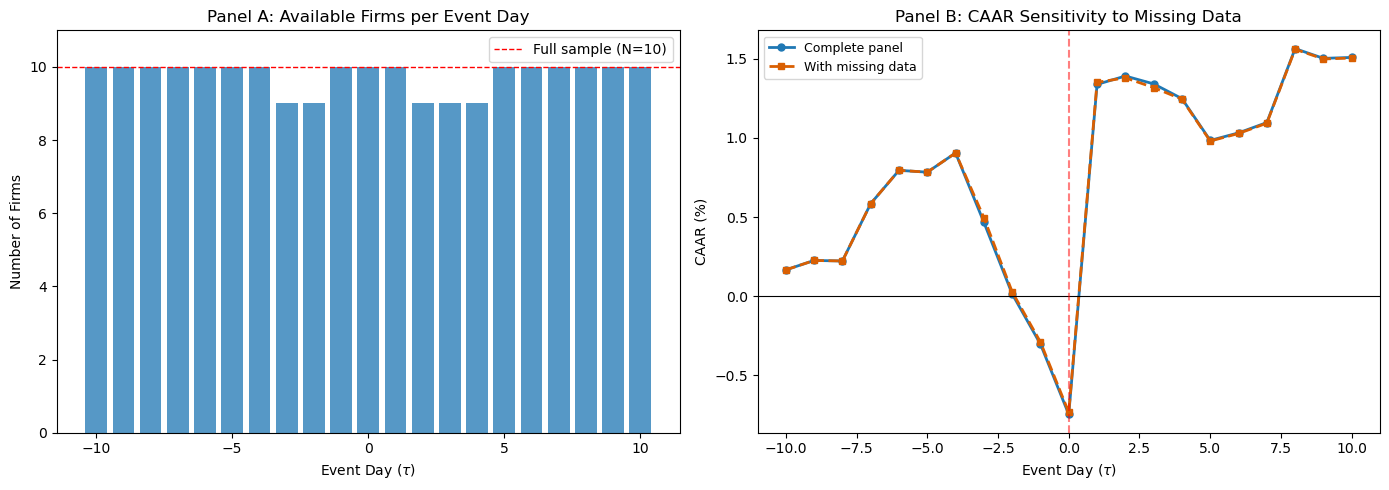

In [15]:
# -- Demonstrate missing-data-robust AAR --
ar_panel_missing = ar_panel.copy()
ar_panel_missing.loc[-3, 'JPM'] = np.nan
ar_panel_missing.loc[-2, 'JPM'] = np.nan
ar_panel_missing.loc[2, 'JNJ'] = np.nan
ar_panel_missing.loc[3, 'JNJ'] = np.nan
ar_panel_missing.loc[4, 'JNJ'] = np.nan

n_available = ar_panel_missing.notna().sum(axis=1)
aar_robust = ar_panel_missing.mean(axis=1)
caar_robust = aar_robust.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(event_days, n_available, color='#2c7fb8', alpha=0.8)
axes[0].axhline(N, color='red', linestyle='--', linewidth=1, label=f'Full sample (N={N})')
axes[0].set_xlabel('Event Day ($\\tau$)')
axes[0].set_ylabel('Number of Firms')
axes[0].set_title('Panel A: Available Firms per Event Day')
axes[0].legend(frameon=True)
axes[0].set_ylim(0, N + 1)

axes[1].plot(event_days, caar * 100, 'o-', color='#1f78b4', linewidth=2,
             markersize=5, label='Complete panel')
axes[1].plot(event_days, caar_robust * 100, 's--', color='#d95f02', linewidth=2,
             markersize=5, label='With missing data')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Event Day ($\\tau$)')
axes[1].set_ylabel('CAAR (%)')
axes[1].set_title('Panel B: CAAR Sensitivity to Missing Data')
axes[1].legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## 8. Graphical Presentation Standards

The graphical presentation of event study results has converged on a set of conventions in the literature. Following these conventions makes results immediately readable to referees and other researchers.

**The CAAR plot** is the primary visual output of an event study. It shows the cumulative average abnormal return on the vertical axis against event time $\tau$ on the horizontal axis. The key elements are: a vertical dashed line at $\tau = 0$ marking the event date, the CAAR path with markers, a 95% confidence band around the CAAR based on the cross-sectional standard error, and a horizontal line at zero for reference.

**The AAR bar chart** is the secondary plot, showing daily average abnormal returns. Positive and negative days are often color-coded. This plot reveals the timing of the price adjustment: a single large bar at $\tau = 0$ indicates a sharp, immediate reaction; bars spread across several days indicate gradual incorporation.

**The individual CAR spaghetti plot** overlays the CAR paths for all firms in the sample. This plot is less common in published papers but is invaluable during the research process, as it reveals outliers, heterogeneity, and potential data errors that the aggregate CAAR would mask.

We now produce all four standard panels for our sample.

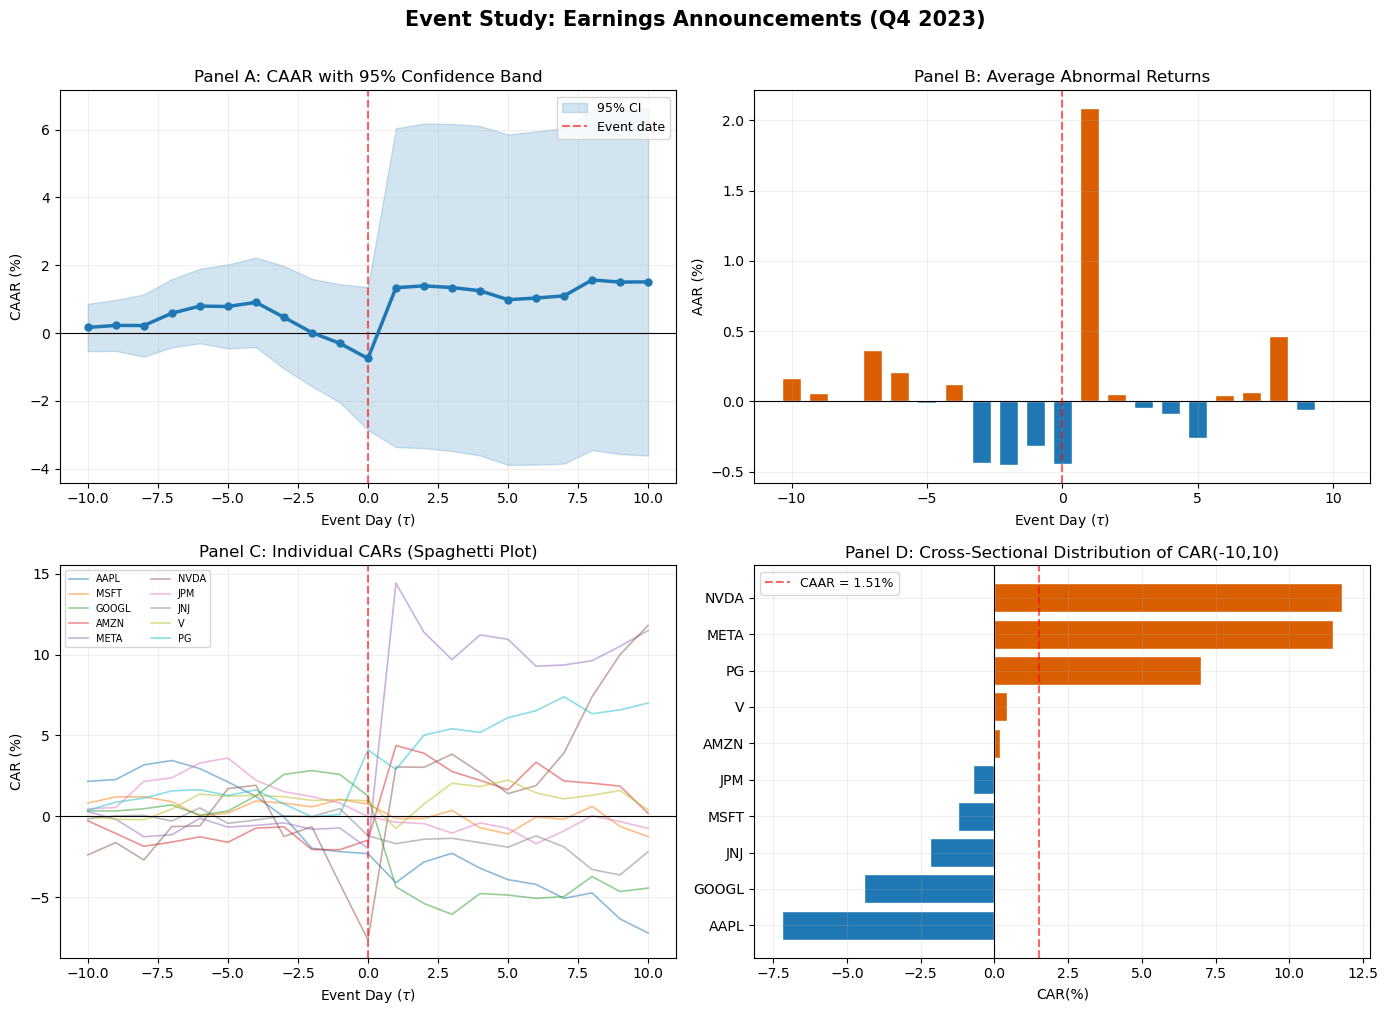

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Panel A: CAAR with confidence band --
ax = axes[0, 0]
ax.plot(event_days, caar * 100, 'o-', color='#1f78b4', linewidth=2.5, markersize=5, zorder=3)
ax.fill_between(event_days, (caar - 1.96 * caar_se) * 100,
                (caar + 1.96 * caar_se) * 100, alpha=0.2, color='#1f78b4', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6, label='Event date')
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('CAAR (%)')
ax.set_title('Panel A: CAAR with 95% Confidence Band')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.2)

# -- Panel B: AAR bar chart --
ax = axes[0, 1]
colors_bar = ['#d95f02' if v >= 0 else '#1f78b4' for v in aar.values]
ax.bar(event_days, aar * 100, color=colors_bar, edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('AAR (%)')
ax.set_title('Panel B: Average Abnormal Returns')
ax.grid(True, alpha=0.2)

# -- Panel C: Individual CAR spaghetti --
ax = axes[1, 0]
for tick in ar_panel.columns:
    car_i = ar_panel[tick].cumsum()
    ax.plot(event_days, car_i * 100, alpha=0.5, linewidth=1.2, label=tick)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('CAR (%)')
ax.set_title('Panel C: Individual CARs (Spaghetti Plot)')
ax.legend(fontsize=7, ncol=2, frameon=True, loc='upper left')
ax.grid(True, alpha=0.2)

# -- Panel D: Cross-sectional dispersion --
ax = axes[1, 1]
car_final = (ar_panel.cumsum().iloc[-1] * 100).sort_values()
colors_cs = ['#d95f02' if v >= 0 else '#1f78b4' for v in car_final.values]
ax.barh(range(len(car_final)), car_final.values, color=colors_cs, edgecolor='white')
ax.set_yticks(range(len(car_final)))
ax.set_yticklabels(car_final.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(caar.iloc[-1] * 100, color='red', linewidth=1.5, linestyle='--',
           alpha=0.6, label=f'CAAR = {caar.iloc[-1]*100:.2f}%')
ax.set_xlabel('CAR(%)')
ax.set_title(f'Panel D: Cross-Sectional Distribution of CAR({event_win[0]},{event_win[1]})')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.2)

fig.suptitle('Event Study: Earnings Announcements (Q4 2023)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Standardized Abnormal Returns

Raw abnormal returns have different variances across firms: a high-volatility stock will have noisier ARs than a low-volatility stock. When computing the AAR, the high-volatility firms contribute more noise to the average, reducing the power of the test.

The solution is to **standardize** each firm's abnormal return by its estimated standard deviation before aggregating. The standardized abnormal return (SAR) is (Patell, 1976):

$$
SAR_{i,\tau} = \frac{AR_{i,\tau}}{\hat{\sigma}_{\varepsilon_i} \sqrt{1 + \frac{1}{L_i} + \frac{(R_{m,\tau} - \hat{\mu}_m)^2}{\sum_{t=1}^{L_i}(R_{m,t} - \hat{\mu}_m)^2}}}
$$

For large estimation windows ($L_i > 100$), the correction terms under the square root are negligible, and the SAR simplifies to $AR_{i,\tau} / \hat{\sigma}_{\varepsilon_i}$.

The standardized AAR is:

$$
SAAR(\tau) = \frac{1}{N} \sum_{i=1}^{N} SAR_{i,\tau}
$$

Under the null, $SAR_{i,\tau}$ follows a Student-$t$ distribution with $L_i - 2$ degrees of freedom (approximately standard normal for large $L_i$). The SAAR has variance $1/N$ under cross-sectional independence, yielding a test statistic $\sqrt{N} \cdot SAAR(\tau) \sim N(0,1)$ under the null. This is the Patell test, which Session 4 develops formally.

The advantage of standardization is that it gives each firm equal weight in the test statistic, regardless of return volatility. The disadvantage is that it does not correspond to a simple average of percentage returns, making economic interpretation less direct.

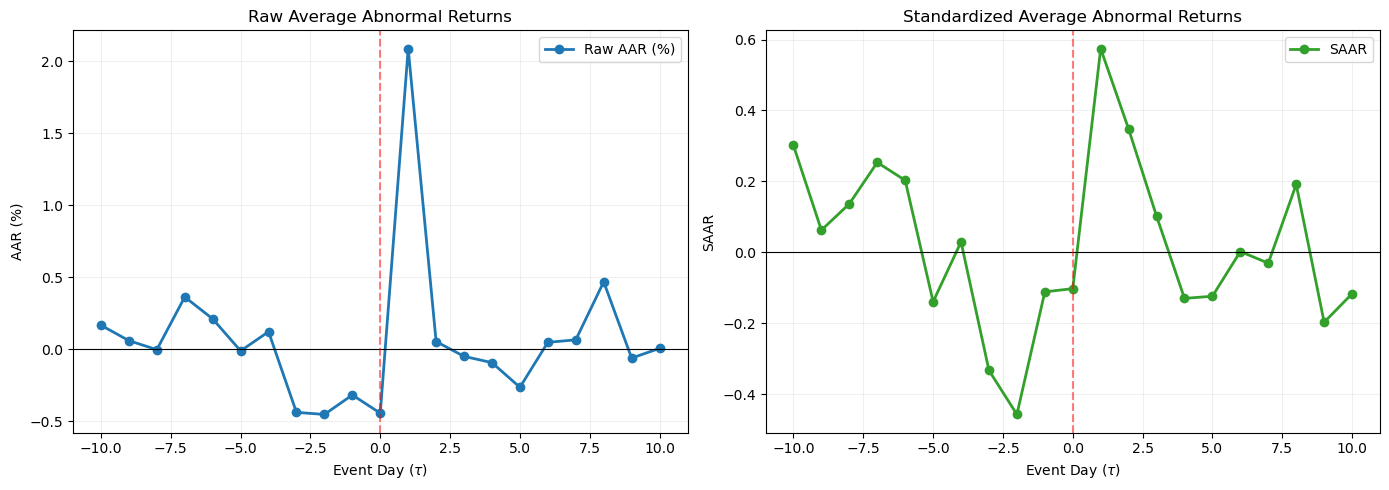

In [21]:
# -- Compute Standardized Abnormal Returns --
sar_panel = pd.DataFrame(index=event_days, columns=events['ticker'].values, dtype=float)

for tick in ar_panel.columns:
    sigma_i = model_params[tick]['sigma']
    sar_panel[tick] = ar_panel[tick] / sigma_i

saar = sar_panel.mean(axis=1)
csaar = saar.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(event_days, aar * 100, 'o-', color='#1f78b4', linewidth=2, label='Raw AAR (%)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Event Day ($\\tau$)')
axes[0].set_ylabel('AAR (%)')
axes[0].set_title('Raw Average Abnormal Returns')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.2)

axes[1].plot(event_days, saar, 'o-', color='#33a02c', linewidth=2, label='SAAR')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Event Day ($\\tau$)')
axes[1].set_ylabel('SAAR')
axes[1].set_title('Standardized Average Abnormal Returns')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 10. Building the Event Study Toolkit

We now assemble the key functions developed across Sessions 1--3 into a reusable module. This toolkit will be imported in all subsequent sessions, avoiding code duplication and ensuring consistency.

The module provides four core functions: `estimate_market_model` (estimate OLS on the estimation window), `compute_abnormal_returns` (compute AR and CAR for a single firm), `aggregate_event_study` (compute AAR, CAAR, and standard errors for a panel), and `plot_event_study` (produce the four-panel figure from Section 8).

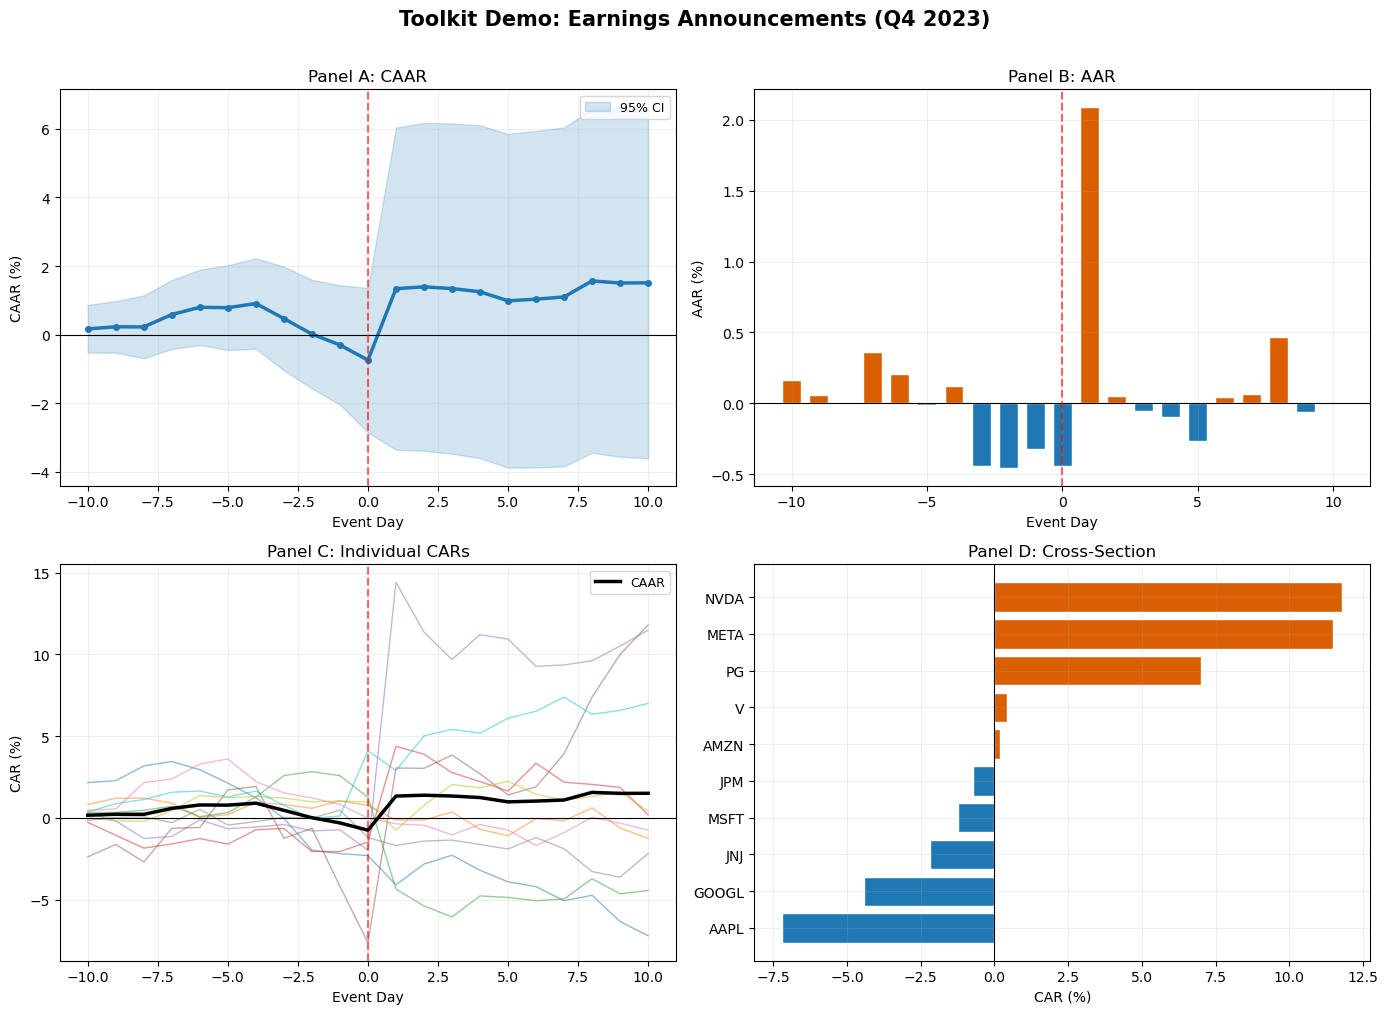

In [23]:
def estimate_market_model(firm_ret, market_ret, est_start, est_end):
    # Estimate market model by OLS. Returns alpha, beta, sigma, ols_result.
    y = firm_ret[est_start:est_end + 1]
    x = market_ret[est_start:est_end + 1]
    valid = ~(np.isnan(y) | np.isnan(x))
    y, x = y[valid], x[valid]
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    return ols.params[0], ols.params[1], np.sqrt(ols.mse_resid), ols


def compute_abnormal_returns(firm_ret, market_ret, alpha, beta, event_start, event_end):
    # Compute AR and CAR for a single firm in the event window.
    y = firm_ret[event_start:event_end + 1]
    x = market_ret[event_start:event_end + 1]
    ar = y - (alpha + beta * x)
    car = np.cumsum(ar)
    return ar, car


def aggregate_event_study(ar_panel):
    # Compute AAR, CAAR, cross-sectional SE, and t-statistics from an AR panel.
    N_t = ar_panel.notna().sum(axis=1)
    aar = ar_panel.mean(axis=1)
    caar = aar.cumsum()
    aar_se = ar_panel.std(axis=1, ddof=1) / np.sqrt(N_t)
    aar_t = aar / aar_se
    caar_var = (aar_se ** 2).cumsum()
    caar_se = np.sqrt(caar_var)
    caar_t = caar / caar_se

    return pd.DataFrame({
        'AAR': aar, 'AAR_SE': aar_se, 'AAR_t': aar_t,
        'CAAR': caar, 'CAAR_SE': caar_se, 'CAAR_t': caar_t, 'N': N_t,
    })


def plot_event_study(agg_df, ar_panel, title='Event Study Results'):
    # Produce the standard four-panel event study figure.
    ed = agg_df.index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(ed, agg_df['CAAR'] * 100, 'o-', color='#1f78b4', linewidth=2.5, markersize=4)
    ax.fill_between(ed, (agg_df['CAAR'] - 1.96 * agg_df['CAAR_SE']) * 100,
                    (agg_df['CAAR'] + 1.96 * agg_df['CAAR_SE']) * 100,
                    alpha=0.2, color='#1f78b4', label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.set_xlabel('Event Day'); ax.set_ylabel('CAAR (%)')
    ax.set_title('Panel A: CAAR'); ax.legend(frameon=True, fontsize=9); ax.grid(True, alpha=0.2)

    ax = axes[0, 1]
    c = ['#d95f02' if v >= 0 else '#1f78b4' for v in agg_df['AAR'].values]
    ax.bar(ed, agg_df['AAR'] * 100, color=c, edgecolor='white', width=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.set_xlabel('Event Day'); ax.set_ylabel('AAR (%)')
    ax.set_title('Panel B: AAR'); ax.grid(True, alpha=0.2)

    ax = axes[1, 0]
    for col in ar_panel.columns:
        ax.plot(ed, ar_panel[col].cumsum() * 100, alpha=0.5, linewidth=1)
    ax.plot(ed, agg_df['CAAR'] * 100, 'k-', linewidth=2.5, label='CAAR')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.set_xlabel('Event Day'); ax.set_ylabel('CAR (%)')
    ax.set_title('Panel C: Individual CARs'); ax.legend(frameon=True, fontsize=9); ax.grid(True, alpha=0.2)

    ax = axes[1, 1]
    cf = (ar_panel.cumsum().iloc[-1] * 100).sort_values()
    c2 = ['#d95f02' if v >= 0 else '#1f78b4' for v in cf.values]
    ax.barh(range(len(cf)), cf.values, color=c2, edgecolor='white')
    ax.set_yticks(range(len(cf))); ax.set_yticklabels(cf.index)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('CAR (%)'); ax.set_title('Panel D: Cross-Section'); ax.grid(True, alpha=0.2)

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# -- Demonstrate the toolkit --
agg_df = aggregate_event_study(ar_panel)
plot_event_study(agg_df, ar_panel, title='Toolkit Demo: Earnings Announcements (Q4 2023)')

## 11. Robust Aggregation: Median and Trimmed Mean

The equal-weighted mean is sensitive to outliers. A single firm with an extreme abnormal return (positive or negative) can dominate the CAAR. Two robust alternatives are widely used.

The **median abnormal return** is the middle value of the cross-sectional distribution on each event day. It is insensitive to outliers and provides a measure of the "typical" firm's experience. The disadvantage is that the median is harder to work with statistically (its variance depends on the density of the distribution at the median, which must be estimated).

The **trimmed mean** drops a fixed fraction of the most extreme observations on each day before computing the mean. A 5% or 10% trim on each tail is common. This retains the tractability of the mean while reducing outlier influence.

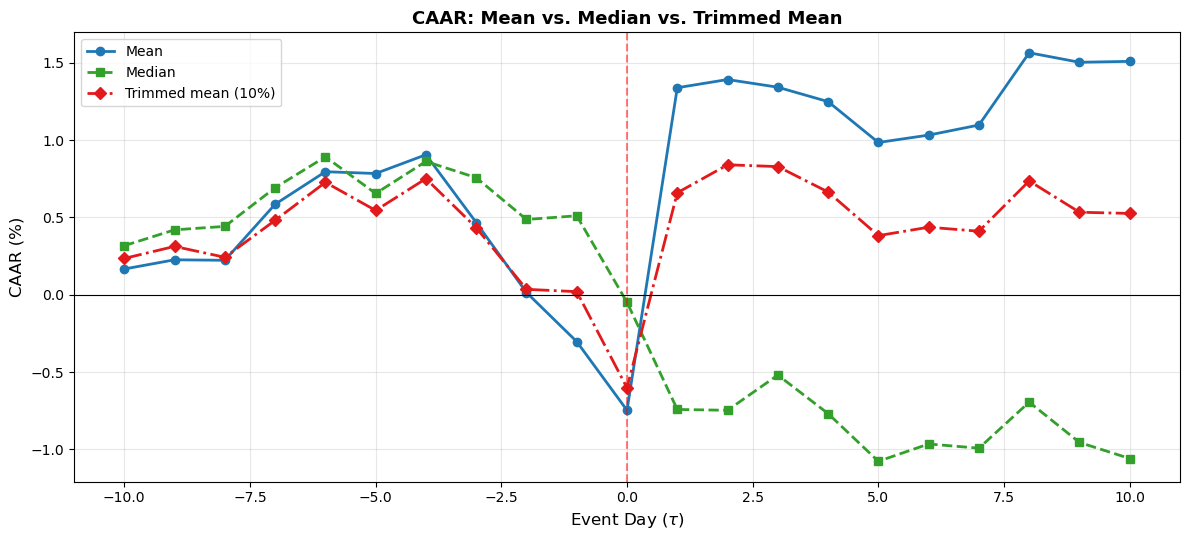

In [25]:
from scipy.stats import trim_mean

aar_median = ar_panel.median(axis=1)
caar_median = aar_median.cumsum()

aar_trimmed = ar_panel.apply(lambda row: trim_mean(row.dropna(), proportiontocut=0.1), axis=1)
caar_trimmed = aar_trimmed.cumsum()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(event_days, caar * 100, 'o-', color='#1f78b4', linewidth=2, label='Mean')
ax.plot(event_days, caar_median * 100, 's--', color='#33a02c', linewidth=2, label='Median')
ax.plot(event_days, caar_trimmed * 100, 'D-.', color='#e31a1c', linewidth=2, label='Trimmed mean (10%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Event Day ($\\tau$)', fontsize=12)
ax.set_ylabel('CAAR (%)', fontsize=12)
ax.set_title('CAAR: Mean vs. Median vs. Trimmed Mean', fontsize=13, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Calendar-Time Clustering

An important assumption in the standard framework is that events do not cluster in calendar time. When they do, the cross-sectional independence assumption fails, and the variance of the CAAR is underestimated.

In our sample, several firms announced earnings on the same dates (January 30, February 1). This means their event windows overlap in calendar time, and their abnormal returns are correlated through exposure to the same market conditions.

To quantify the extent of clustering, we compute the fraction of event-window days that overlap across firms and examine the calendar-time distribution of our events.

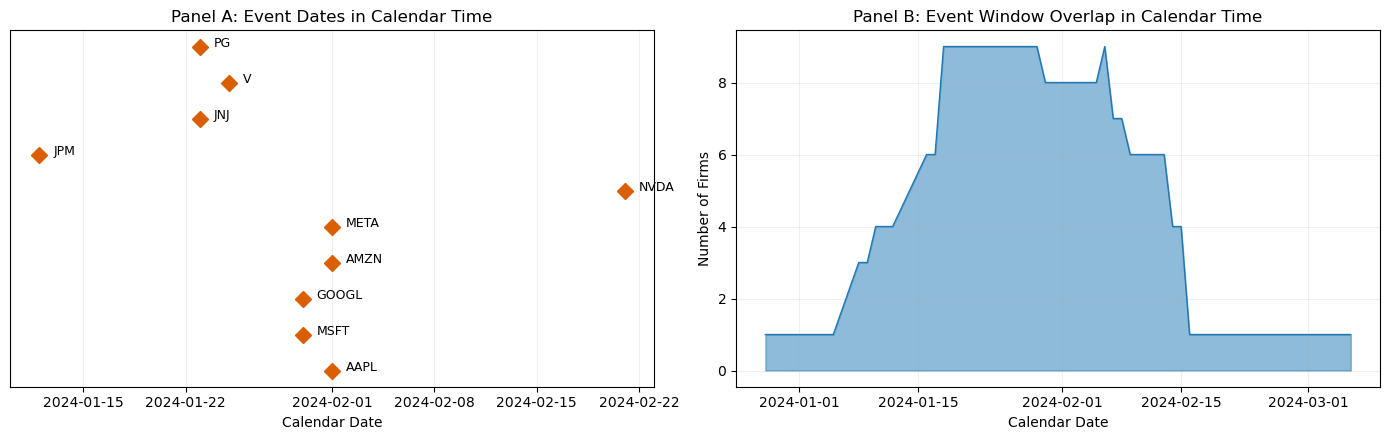


Maximum overlap: 9 firms share event-window day 2024-01-18
Mean overlap per calendar day: 4.5 firms


In [27]:
from collections import Counter

overlap_data = {}
for _, row in events.iterrows():
    tick = row['ticker']
    edate = row['event_date']
    event_idx = trading_days.get_indexer([edate], method='ffill')[0]
    cal_dates = trading_days[event_idx + event_win[0]: event_idx + event_win[1] + 1]
    overlap_data[tick] = set(cal_dates)

all_cal_dates = []
for dates in overlap_data.values():
    all_cal_dates.extend(dates)
date_counts = Counter(all_cal_dates)

overlap_df = pd.DataFrame.from_dict(date_counts, orient='index', columns=['N_firms'])
overlap_df = overlap_df.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for i, (_, row) in enumerate(events.iterrows()):
    edate = row['event_date']
    ax.plot(edate, i, 'D', color='#d95f02', markersize=8)
    ax.annotate(row['ticker'], (edate, i), textcoords="offset points",
                xytext=(10, 0), fontsize=9)
ax.set_yticks([])
ax.set_xlabel('Calendar Date')
ax.set_title('Panel A: Event Dates in Calendar Time')
ax.grid(True, alpha=0.2, axis='x')

ax = axes[1]
ax.fill_between(overlap_df.index, 0, overlap_df['N_firms'], alpha=0.5, color='#1f78b4')
ax.plot(overlap_df.index, overlap_df['N_firms'], color='#1f78b4', linewidth=1)
ax.set_xlabel('Calendar Date')
ax.set_ylabel('Number of Firms')
ax.set_title('Panel B: Event Window Overlap in Calendar Time')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

max_overlap_date = overlap_df['N_firms'].idxmax()
max_overlap_n = overlap_df['N_firms'].max()
print(f"\nMaximum overlap: {max_overlap_n} firms share event-window day {max_overlap_date.date()}")
print(f"Mean overlap per calendar day: {overlap_df['N_firms'].mean():.1f} firms")

The overlap analysis reveals the extent of calendar-time clustering. When many firms share the same calendar dates in their event windows, the standard errors computed under the independence assumption are too small, leading to over-rejection. Session 4 will introduce test statistics that are robust to this clustering, including the Boehmer-Musumeci-Poulsen (BMP) test and the Kolari-Pynnonen adjustment.

## 13. Summary and Preview of Session 4

This session addressed the aggregation of abnormal returns across firms, which is the step that transforms an event study from a firm-level exercise into a cross-sectional test of an economic hypothesis.

The key results are as follows. The AAR and CAAR are computed by averaging (raw or standardized) abnormal returns across firms and cumulating over event time. The variance of the CAAR depends on whether the events are cross-sectionally independent; when they are not (calendar-time clustering), the cross-sectional variance estimator provides a robust alternative. Equal-weighted and value-weighted aggregation answer different economic questions, and reporting both is advisable. Missing data requires careful treatment, and the researcher should document the pattern of attrition. The standardized abnormal return (Patell, 1976) equalizes the contribution of each firm to the test statistic, improving power when firms have heterogeneous return volatilities. Robust alternatives (median, trimmed mean) guard against outliers.

We also established the graphical standards for reporting: the four-panel figure (CAAR with confidence band, AAR bars, individual CAR spaghetti, cross-sectional distribution) is now our template. The reusable toolkit functions (`estimate_market_model`, `compute_abnormal_returns`, `aggregate_event_study`, `plot_event_study`) will be imported in all subsequent sessions.

Session 4 introduces the parametric test statistics that formalize the hypothesis testing: the classical t-test, the Patell test, the BMP test, and corrections for cross-sectional dependence. With the aggregation machinery from this session in place, we are ready to ask: is the CAAR statistically significantly different from zero?

**Additional references:**

- Corrado, C.J. (1989). A Nonparametric Test for Abnormal Security-Price Performance in Event Studies. *Journal of Financial Economics*, 23(2), 385--395.
- Fama, E.F. (1998). Market Efficiency, Long-Term Returns, and Behavioral Finance. *Journal of Financial Economics*, 49(3), 283--306.
- Schipper, K. and Thompson, R. (1983). The Impact of Merger-Related Regulations on the Shareholders of Acquiring Firms. *Journal of Accounting Research*, 21(1), 184--221.